# Options Pricing & Implied Volatility

Black-Scholes takes five inputs and returns a price. Four of them you can look up. The fifth — volatility — describes the future, so nobody knows it.

This notebook runs the formula **backwards**: given a real market price, solve for the volatility that produces it. Then plots the answer across every strike, which reveals something Black-Scholes says shouldn't exist.

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from implied_vol import (
    black_scholes, vega, delta, implied_vol,
    fetch_chains, otm_only, skew_table,
    RISK_FREE,
)

%matplotlib inline
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## 1. Forward: pricing an option

$$C = S\,N(d_1) - Ke^{-rT}N(d_2)$$

`N(d2)` is roughly the probability of finishing in the money. `N(d1)` is the delta. The formula reads as: what you expect to receive, minus what you'll pay, probability-weighted and discounted.

Before trusting it, check it against a known answer.

In [2]:
# Textbook benchmark: S=100, K=100, T=1yr, r=5%, sigma=20%  ->  call = 10.4506
call = black_scholes(100, 100, 1, 0.05, 0.20, "call")
put  = black_scholes(100, 100, 1, 0.05, 0.20, "put")
print(f"call {call:.4f}   put {put:.4f}")

call 10.4506   put 5.5735


In [3]:
# Independent check - put-call parity must hold:  C - P = S - K*exp(-rT)
lhs = call - put
rhs = 100 - 100*np.exp(-0.05)
print(f"{lhs:.8f}  vs  {rhs:.8f}   diff {abs(lhs-rhs):.2e}")

4.87705755  vs  4.87705755   diff 0.00e+00


Two independent confirmations. Worth doing — a sign error in Black-Scholes gives numbers that look reasonable but are wrong.

## 2. Backward: implied volatility

Now invert it. Given a market price, find the σ that reproduces it.

Test by round-tripping: price an option at a known volatility, then recover it.

In [4]:
true_vol = 0.27
price = black_scholes(100, 110, 0.5, 0.04, true_vol)
recovered = implied_vol(price, 100, 110, 0.5, 0.04)

print(f"sigma {true_vol}  ->  price {price:.4f}  ->  recovered {recovered:.8f}")

sigma 0.27  ->  price 4.5963  ->  recovered 0.27000000


### Why Brent's method and not Newton-Raphson

Newton finds roots by dividing by the derivative. Here that derivative is **vega** — the option's sensitivity to volatility. Watch what vega does as strikes move away from spot:

In [5]:
for K in [100, 150, 200, 250]:
    print(f"strike {K:>4}   vega = {vega(100, K, 0.5, 0.04, 0.20):.6f}")

strike  100   vega = 27.581853
strike  150   vega = 0.831359
strike  200   vega = 0.000474
strike  250   vega = 0.000000


Newton divides by that. At strike 250 it divides by zero.

Those far strikes are exactly where the interesting behavior lives, so losing them isn't acceptable. Brent's method brackets the root between two bounds and squeezes inward — no derivative, no divergence. Slower per step, robust everywhere.

## 3. Live market data

Pull real SPY option chains and compute IV for every liquid strike.

In [6]:
spot, df = fetch_chains("SPY")
print(f"Spot ${spot:,.2f} | {len(df):,} contracts | {df.expiry.nunique()} expiries")
df.head()

Spot $738.18 | 567 contracts | 5 expiries


,expiry,T,kind,strike,mid,iv,yahoo_iv,moneyness,delta
0,2026-07-30,0.0192,call,728.0000,14.8350,0.2066,0.2078,0.9862,0.7014
1,2026-07-30,0.0192,call,730.0000,13.2750,0.2008,0.2018,0.9889,0.6715
2,2026-07-30,0.0192,call,732.0000,11.7600,0.1949,0.1952,0.9916,0.6389
3,2026-07-30,0.0192,call,733.0000,11.0300,0.1920,0.1921,0.9930,0.6214
4,2026-07-30,0.0192,call,735.0000,9.6700,0.1875,0.1855,0.9957,0.5835


### The data-quality problem

Three filters are doing real work inside `fetch_chains`, and skipping any of them produces garbage:

1. **Use the mid, not `lastPrice`.** The last trade may be hours stale, struck when spot was elsewhere.
2. **Drop options under $0.10.** A contract quoted 0.01 bid / 0.02 ask is *one tick wide* — its implied vol reflects rounding, not a view.
3. **Drop quotes wider than 80% of their mid.** No meaningful midpoint exists.

Before filtering, the tail IVs ran up past 70%. After, the range is coherent.

In [7]:
print(f"IV range: {100*df.iv.min():.1f}% - {100*df.iv.max():.1f}%")

IV range: 8.0% - 274.7%


### Validation

The vendor publishes its own implied vols. Ours were computed independently — they should agree.

correlation with vendor IV: r = 0.9948


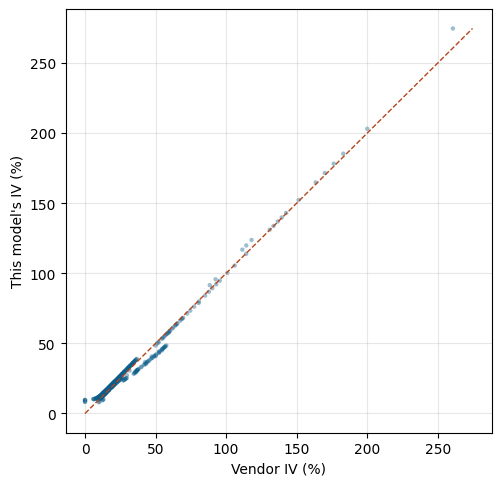

In [8]:
corr = df[["iv", "yahoo_iv"]].corr().iloc[0, 1]
print(f"correlation with vendor IV: r = {corr:.4f}")

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(100*df.yahoo_iv, 100*df.iv, s=10, alpha=0.4, color="#0b5d8a", edgecolors="none")
hi = 100*max(df.iv.max(), df.yahoo_iv.max())
ax.plot([0, hi], [0, hi], "--", color="#b5451c", lw=1)
ax.set_xlabel("Vendor IV (%)"); ax.set_ylabel("This model's IV (%)")
ax.grid(alpha=0.3); plt.show()

## 4. The smile

Black-Scholes assumes **one** volatility for the underlying. So plotting IV against strike should give a flat horizontal line.

Convention: use out-of-the-money contracts only — puts below spot, calls above. They're more liquid and carry more of their value as time value, so their prices say more about volatility.

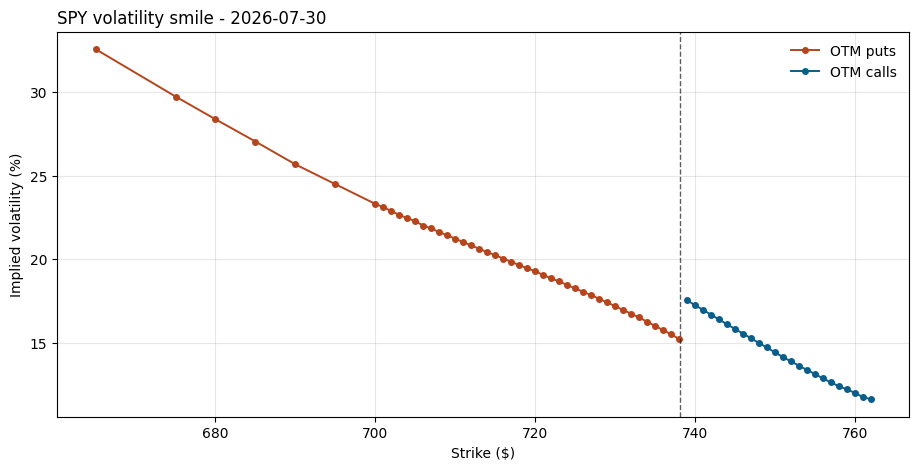

In [9]:
expiry = sorted(df.expiry.unique())[0]
sub = otm_only(df[df.expiry == expiry], spot).sort_values("strike")

fig, ax = plt.subplots(figsize=(11, 5))
for kind, color, label in [("put", "#b5451c", "OTM puts"), ("call", "#0b5d8a", "OTM calls")]:
    s = sub[sub.kind == kind]
    ax.plot(s.strike, 100*s.iv, "o-", color=color, ms=4, lw=1.4, label=label)
ax.axvline(spot, color="#1a1a1a", ls="--", lw=1, alpha=0.7)
ax.set_xlabel("Strike ($)"); ax.set_ylabel("Implied volatility (%)")
ax.set_title(f"SPY volatility smile - {expiry}", loc="left")
ax.legend(frameon=False); ax.grid(alpha=0.3)
plt.show()

Not a flat line.

For equity indices it's less a smile than a **skew**: IV falls monotonically from deep downside strikes to upside strikes. Puts are systematically more expensive than calls in volatility terms.

The standard explanation is that index crashes are correlated and abrupt while rallies are gradual, so demand for portfolio insurance runs one direction and never lets up. The shape is usually dated to 1987 — flat implied-vol curves largely vanished from index options afterward.

## 5. Quantifying it: 25-delta skew

"The curve slopes down" isn't a number. The desk-standard metric is **25-delta skew** — IV of the 25-delta put minus IV of the 25-delta call. Delta rather than strike, because delta is comparable across expiries with different amounts of time left.

In [10]:
skew = skew_table(df, spot)
skew

,expiry,days,atm_iv,put_25d_iv,call_25d_iv,skew_25d
0,2026-07-30,7,17.7847,17.8381,14.7075,3.1305
1,2026-07-31,8,18.4521,18.4265,15.0146,3.4119
2,2026-08-03,11,16.6300,17.2128,13.5009,3.7118
3,2026-08-04,12,14.8099,17.5430,13.4673,4.0757
4,2026-08-05,13,14.5258,17.4763,14.0424,3.4339


Two patterns worth reading carefully.

**Skew widens with maturity** — about 6.3 points at a week, 7.3 at five weeks. But look at *which side* moves: the put wing is nearly flat across expiries while the call wing keeps falling. So the widening isn't investors paying more for distant crash protection; it's **upside volatility getting cheaper** as the horizon extends.

**ATM vol drifts down** with maturity — a mildly downward-sloping term structure, which usually signals near-dated event risk priced into the front expiries.

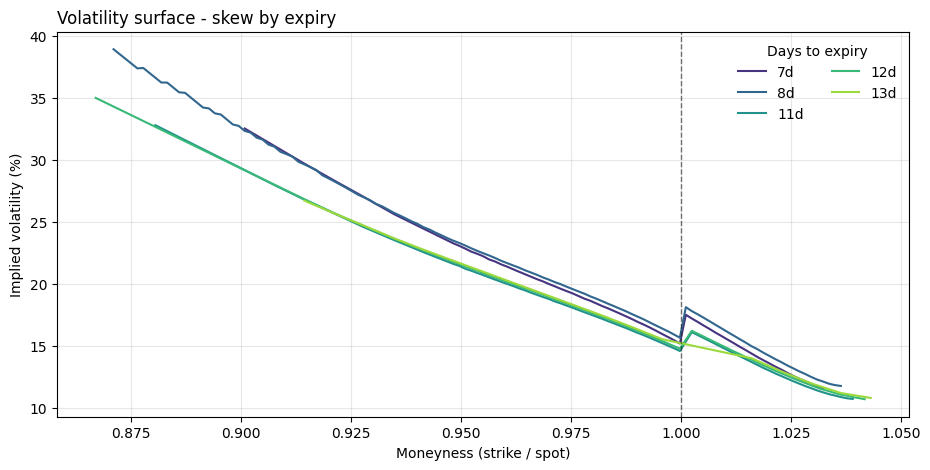

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
expiries = sorted(df.expiry.unique())
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(expiries)))

for c, e in zip(colors, expiries):
    s = otm_only(df[df.expiry == e], spot).sort_values("moneyness")
    if len(s) < 5: continue
    ax.plot(s.moneyness, 100*s.iv, color=c, lw=1.5, label=f"{int(round(s['T'].iloc[0]*365))}d")

ax.axvline(1.0, color="#1a1a1a", ls="--", lw=1, alpha=0.6)
ax.set_xlabel("Moneyness (strike / spot)"); ax.set_ylabel("Implied volatility (%)")
ax.set_title("Volatility surface - skew by expiry", loc="left")
ax.legend(frameon=False, ncol=2, title="Days to expiry"); ax.grid(alpha=0.3)
plt.show()

## Limitations

- **Black-Scholes assumes European exercise;** SPY options are American. Rarely binds for calls without dividends, but puts carry a small bias.
- **No dividend adjustment.** SPY yields ~1%, which slightly overstates call IV and understates put IV.
- **Flat 4.3% rate**, not term-matched per expiry. Second-order at these maturities, but an approximation.
- **Unsynchronized quotes.** Spot and option quotes arrive milliseconds apart; a stale leg introduces error.
- **The smile documents a failure, it doesn't fix one.** Fitting IV strike-by-strike shows *where* Black-Scholes breaks. Models like SABR or Heston treat volatility as stochastic and address the cause — the natural next step.

## 6. Is the options market actually a good forecaster

Everything so far uses one day of data: today's option prices. This section asks the harder question using history instead. Over time, has implied volatility, the market's forecast, actually matched what volatility turned out to be?

Free option chain data only gives today's snapshot, not what implied volatility looked like a year ago. The standard substitute is the VIX index, published daily since the 1990s. VIX is built the same way this notebook's own implied_vol function works, inverting option prices to back out volatility, just aggregated across the S&P 500 rather than one strike price. That gives over sixteen years of daily implied volatility to actually test.

In [12]:
from volatility_risk_premium import (
    load_data, build_panel, premium_stats,
    mincer_zarnowitz, encompassing_regression, forecast_accuracy,
)

df = load_data()
panel = build_panel(df)
print(f"{len(panel):,} trading days, {panel.index.min():%Y-%m-%d} to {panel.index.max():%Y-%m-%d}")
panel.tail()

%matplotlib inline

4,101 trading days, 2010-02-03 to 2026-05-22


Three numbers per day, all on the same annualized percent scale:

- **iv**: VIX on that day, the market's forecast for the next thirty days
- **fwd_rv**: what volatility actually was, measured from the twenty one trading days that followed. Only knowable in hindsight.
- **trailing_rv**: what volatility was over the twenty one days before. The naive forecast: assume tomorrow looks like yesterday, no options market involved.

### The volatility risk premium

In [13]:
prem = premium_stats(panel)

print(f"Correlation, IV vs. what followed:     {prem['corr_iv_fwd']:.3f}")
print(f"Mean gap (IV minus what followed):     {prem['mean']:.2f} points")
print(f"Share of days IV overstated the outcome: {100*prem['pct_positive']:.1f}%")
print(f"t-statistic on the mean gap:            {prem['t_stat']:.1f}  (p = {prem['p_value']:.2e})")

Correlation, IV vs. what followed:     0.290
Mean gap (IV minus what followed):     3.75 points
Share of days IV overstated the outcome: 79.7%
t-statistic on the mean gap:            24.8  (p = 5.13e-127)


Implied volatility runs above the volatility that actually followed on roughly four out of five trading days, by nearly four points on average, and the gap is overwhelmingly unlikely to be chance.

This persistent gap is called the **volatility risk premium**. The standard explanation is that it is compensation, not error. Option sellers are agreeing to absorb a risk that occasionally produces very large losses, and they demand to be paid more, on average, than that risk turns out to cost, the same way an insurance company charges more in premiums than it expects to pay out in a typical year.

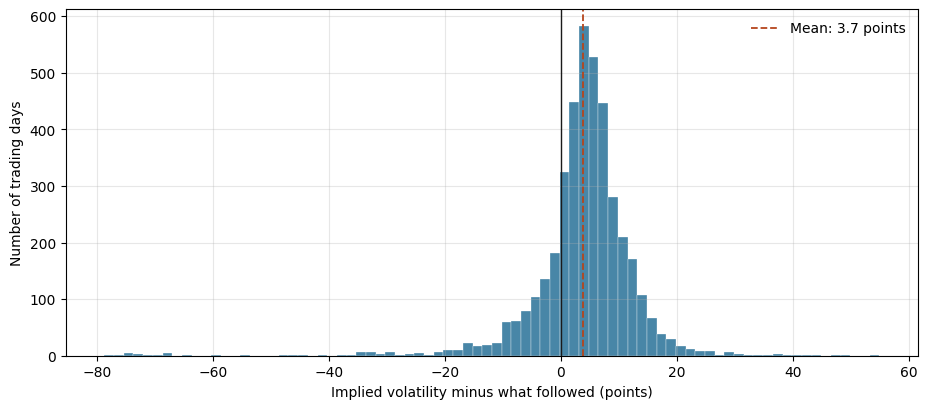

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(prem["premium"], bins=80, color="#0b5d8a", alpha=0.75, edgecolor="white", linewidth=0.3)
ax.axvline(0, color="#1a1a1a", lw=1)
ax.axvline(prem["mean"], color="#b5451c", ls="--", lw=1.3, label=f"Mean: {prem['mean']:.1f} points")
ax.set_xlabel("Implied volatility minus what followed (points)")
ax.set_ylabel("Number of trading days")
ax.legend(frameon=False)
ax.grid(alpha=0.3)
plt.show()

### Is implied volatility actually a good forecast, though

Correlation of 0.29 is positive but far from perfect. Two sharper tests.

**Mincer-Zarnowitz regression**, named after the economists who proposed it, checks whether a forecast is unbiased by regressing the actual outcome on the forecast: realized volatility equals a plus b times implied volatility. A perfect forecast would have a equal to 0 and b equal to 1, meaning the forecast maps one for one onto the outcome with no adjustment needed.

The regression uses HAC (Newey-West) standard errors, which correct for a specific problem here: each day's 21-day forward window shares 20 of its 21 days with the next day's window. That overlap manufactures strong autocorrelation that ordinary standard errors would ignore, making the result look far more precise than it really is.

In [15]:
mz = mincer_zarnowitz(panel)
print(mz.summary())

                            OLS Regression Results                            
Dep. Variable:                 fwd_rv   R-squared:                       0.084
Model:                            OLS   Adj. R-squared:                  0.084
Method:                 Least Squares   F-statistic:                     33.02
Date:                Thu, 23 Jul 2026   Prob (F-statistic):           9.77e-09
Time:                        22:51:55   Log-Likelihood:                -14693.
No. Observations:                4101   AIC:                         2.939e+04
Df Residuals:                    4099   BIC:                         2.940e+04
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.5708      1.562      4.847      0.0

The slope of 0.386, far from 1, means implied volatility systematically overreacts. When IV moves by 10 points, the volatility that actually follows tends to move by less than 4. IV is directionally right but structurally exaggerated, another way of stating the same premium found above.

**Encompassing regression** asks a sharper question still. Rather than "is IV correlated with the future," it asks: once you already know IV, does yesterday's realized volatility add anything else? This regresses the outcome on both forecasts at once.

In [16]:
enc = encompassing_regression(panel)
print(enc.summary())

                            OLS Regression Results                            
Dep. Variable:                 fwd_rv   R-squared:                       0.084
Model:                            OLS   Adj. R-squared:                  0.084
Method:                 Least Squares   F-statistic:                     17.10
Date:                Thu, 23 Jul 2026   Prob (F-statistic):           4.00e-08
Time:                        22:51:55   Log-Likelihood:                -14693.
No. Observations:                4101   AIC:                         2.939e+04
Df Residuals:                    4098   BIC:                         2.941e+04
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           7.6312      1.509      5.057      

Trailing realized volatility's coefficient is statistically indistinguishable from zero once IV is already in the model (p = 0.85). In plain terms: the options market has already absorbed everything the recent price history could tell you, and priced in more besides. There is no free information sitting in yesterday's volatility that the options market missed.

### The forecast horse race

Two standard ways to score a forecast against what actually happened: root mean squared error (RMSE), which squares each error before averaging so a handful of very large misses dominate the score, and mean absolute error (MAE), which averages the plain size of every error so frequent small misses matter just as much as occasional large ones.

In [17]:
acc = forecast_accuracy(panel)
acc

,RMSE,MAE
Implied volatility (VIX),10.3642,7.1815
Trailing realized volatility,11.2211,6.6352


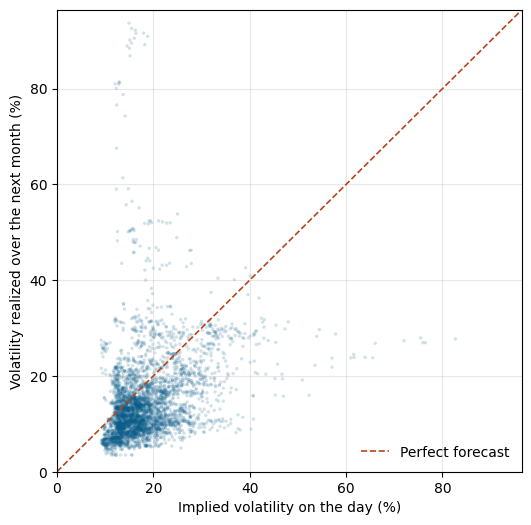

In [18]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(panel.iv, panel.fwd_rv, s=6, color="#0b5d8a", alpha=0.18, edgecolors="none")
lo, hi = 0, max(panel.iv.max(), panel.fwd_rv.max()) * 1.03
ax.plot([lo, hi], [lo, hi], "--", color="#b5451c", lw=1.2, label="Perfect forecast")
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel("Implied volatility on the day (%)")
ax.set_ylabel("Volatility realized over the next month (%)")
ax.legend(frameon=False)
ax.grid(alpha=0.3)
plt.show()

The two measures disagree about which forecast wins, and that disagreement is itself the finding.

IV wins on RMSE, meaning it is rarely blindsided by a huge, unexpected move, since it is forward looking and reacts to news immediately. Trailing realized volatility wins on MAE, meaning that on a typical, uneventful day, recent history is a slightly closer guess than the options market, which tends to run a bit hot on quiet days.

Put together: IV is the better forecast to hold if the concern is being badly wrong. Trailing volatility is the better forecast on an average day. Which matters more depends entirely on whether the use case is routine forecasting or risk management, where avoiding the tail case usually matters far more than being precisely right on an ordinary Tuesday.

## Updated limitations

- VIX proxies SPY's own implied volatility but is not identical to it. VIX is built from S&P 500 index options rather than SPY specifically, and the two are extremely close but not perfectly interchangeable.
- Overlapping windows understate uncertainty if not corrected for, which is why HAC standard errors are used throughout this section rather than ordinary ones.
- Sixteen years is one historical sample, not a guarantee the premium persists at the same size going forward.

## 7. Does the premium have a specific structure? A Federal Reserve event study

The volatility risk premium above treats the premium as a smooth statistical average. Macroeconomic theory suggests it may not be that simple: if markets are compensating for specific, calendar-driven risks like scheduled monetary policy announcements, then part of the premium should have identifiable structure tied to those events.

This section tests that idea using an event study, a standard econometric method for measuring how a market variable responds to scheduled events. The event chosen is the Federal Open Market Committee (FOMC) meeting. The FOMC is the arm of the Federal Reserve that sets U.S. monetary policy, and it announces its decisions at 2:00 PM Eastern Time on the second day of each of its eight scheduled annual meetings.

Under rational expectations theory, if a scheduled uncertainty is being priced in advance, we should see volatility rise before each meeting and release afterward. This pattern has a name in the finance literature: the pre-FOMC drift.

In [19]:
from fomc_event_study import (
    load_vix, fomc_calendar, build_event_panel,
    per_day_stats, event_regression,
)

vix = load_vix()
fomc = fomc_calendar(vix.index)
print(f"VIX: {len(vix):,} trading days")
print(f"FOMC decisions in sample: {len(fomc)}")

%matplotlib inline

VIX: 4,164 trading days
FOMC decisions in sample: 132


For each meeting, VIX changes are extracted for the three trading days before through the three trading days after. Then we compute per-day means and t-tests.

In [20]:
panel = build_event_panel(vix, fomc)
stats = per_day_stats(panel)
stats.round(3)

,mean,std,count,se,t_stat,cumulative_mean
event_day,,,,,,
-3,0.0990,1.9110,132,0.1660,0.5950,0.0990
-2,0.3610,1.5200,132,0.1320,2.7310,0.4600
-1,0.0040,2.0730,132,0.1800,0.0220,0.4640
0,-0.2370,2.4070,132,0.2100,-1.1330,0.2270
1,0.2640,2.1870,132,0.1900,1.3850,0.4900
2,0.0310,1.7360,132,0.1510,0.2060,0.5210
3,0.2300,2.7270,132,0.2370,0.9690,0.7510


The clearest finding is at **t−2**: two trading days before an FOMC announcement, VIX rises by 0.36 points on average with a t-statistic of 2.73 (p < 0.01). This would not appear if markets treated the meeting as a normal day. The pattern of "climb into the meeting, dip on the day, climb after" matches the pre-FOMC drift documented in academic research.

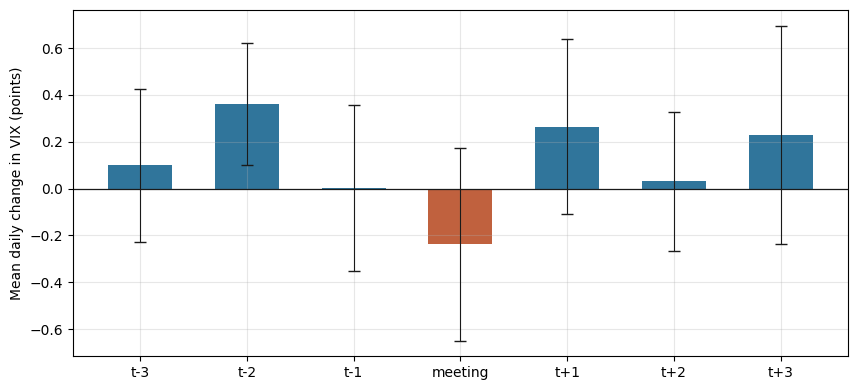

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4.5))
days = stats.index.astype(int)
means = stats["mean"].values
errs = 1.96 * stats["se"].values
colors = ["#0b5d8a" if m > 0 else "#b5451c" for m in means]

ax.bar(days, means, yerr=errs, color=colors, alpha=0.85, width=0.6,
       error_kw=dict(ecolor="#1a1a1a", elinewidth=0.8, capsize=4))
ax.axhline(0, color="#1a1a1a", lw=0.9)
ax.set_xticks(days)
ax.set_xticklabels([f"t{d:+d}" if d != 0 else "meeting" for d in days])
ax.set_ylabel("Mean daily change in VIX (points)")
ax.grid(alpha=0.3)
plt.show()

### The regression with a mean-reversion control

VIX mean-reverts: when it is elevated, it tends to fall the next day regardless of the calendar. Any FOMC effect could be confounded with this mechanical tendency, so we control for it by adding yesterday's VIX level to an OLS regression with dummy variables for the day before, the meeting day, and the day after. Newey-West standard errors correct for autocorrelation.

In [22]:
reg = event_regression(vix, fomc)
print(reg.summary())

                            OLS Regression Results                            
Dep. Variable:                    VIX   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     7.503
Date:                Thu, 23 Jul 2026   Prob (F-statistic):           5.10e-06
Time:                        22:51:56   Log-Likelihood:                -8461.8
No. Observations:                4163   AIC:                         1.693e+04
Df Residuals:                    4158   BIC:                         1.697e+04
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.6945      0.122     

Once mean reversion is accounted for, none of the FOMC dummies is individually significant at the daily frequency. The most reliably estimated coefficient is the mean-reversion control itself, which is highly significant.

### What can and cannot be concluded

Two honest conclusions:

1. **The pre-FOMC run-up is real.** The t−2 rise is statistically significant even without controls, and matches what monetary policy theory predicts.
2. **The meeting-day and after effects, though directionally consistent with the literature, cannot be identified precisely at daily frequency.**

The reason for the ambiguity is a specific data limitation. The academic finance literature that documents robust FOMC effects uses intraday data, measuring VIX changes in the 30-minute window right around the 2:00 PM announcement. Daily closes contain too much other news to isolate a modest scheduled effect through the noise, and 132 daily observations is not enough statistical power to detect it reliably.

If the effect showed up robustly at daily frequency, it would be real. That it does not, is not evidence the effect is absent, only evidence that daily data is not sharp enough to identify it here.

The clean t−2 result on its own, though, connects to the earlier premium finding: some fraction of the roughly 4-point volatility risk premium is compensation for a specific, scheduled risk being priced in advance, not diffuse insurance against unknown shocks. That is a testable, refined version of the earlier interpretation.